In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

DATA = r'../data/processed/'

df = pd.read_csv(DATA + 'dengue_features_modelado.csv', low_memory=False)
df['divipola'] = df['divipola'].astype(str).str.zfill(5)

print(f'Dataset mensual  : {len(df):,} filas | {df["divipola"].nunique()} municipios')
print(f'Período          : {df["ANO"].min()} – {df["ANO"].max()}')
print(f'Columnas totales : {df.shape[1]}')
print(df.dtypes.head(10))

Dataset mensual  : 111,795 filas | 1182 municipios
Período          : 2007 – 2025
Columnas totales : 34
divipola                    object
COD_MUN_O                    int64
Departamento_ocurrencia     object
ANO                          int64
MES                          int64
grave                        int64
grave_lag_1                float64
grave_lag_2                float64
grave_lag_3                float64
grave_lag_4                float64
dtype: object


In [2]:
# DIVIPOLA ya viene computado por build_features.py:
#   COD_DPTO_O.zfill(2) + COD_MUN_O.zfill(3)  →  clave única nacional de 5 dígitos
# Esto evita la ambigüedad de COD_MUN_O=1 que comparten 33 municipios distintos.

print(f'divipola únicos  : {df["divipola"].nunique()}  (vs COD_MUN_O únicos: {df["COD_MUN_O"].nunique()})')
print(f'Municipios con grave > 0 al menos un mes: {df[df["grave"]>0]["divipola"].nunique()}')
print(f'Municipios endémicos (es_endemico=1)    : {df[df["es_endemico"]==1]["divipola"].nunique()}')

divipola únicos  : 1182  (vs COD_MUN_O únicos: 583)
Municipios con grave > 0 al menos un mes: 894
Municipios endémicos (es_endemico=1)    : 139


## 1. Variable objetivo

=== Distribución de casos graves mensuales por municipio ===
count    111795.000000
mean          0.448151
std           3.246508
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         250.000000
Name: grave, dtype: float64

Filas con grave = 0 : 94,081 (84.2%)
Filas con grave > 0 : 17,714 (15.8%)


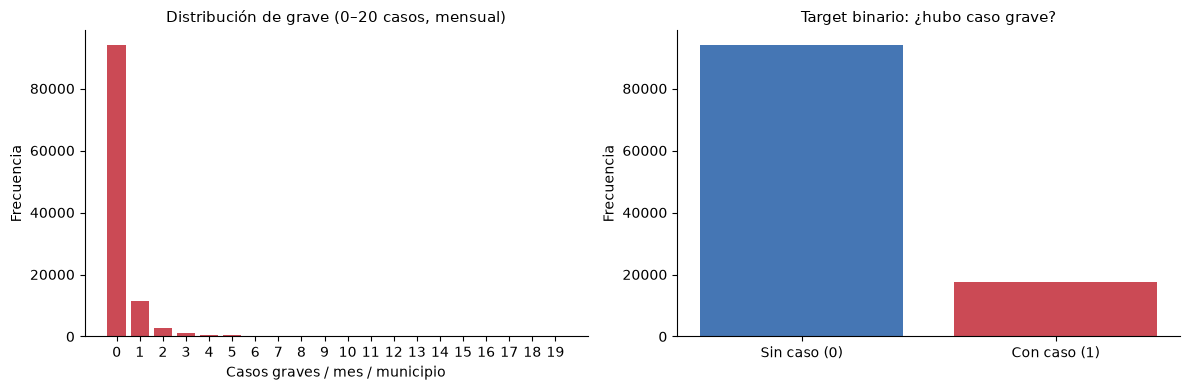

In [3]:
print('=== Distribución de casos graves mensuales por municipio ===')
print(df['grave'].describe())
print(f"\nFilas con grave = 0 : {(df['grave']==0).sum():,} ({(df['grave']==0).mean()*100:.1f}%)")
print(f"Filas con grave > 0 : {(df['grave']>0).sum():,} ({(df['grave']>0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df['grave'].value_counts().sort_index().head(20)
axes[0].bar(vc.index.astype(str), vc.values, color='#BE1D2B', alpha=0.8)
axes[0].set_title('Distribución de grave (0–20 casos, mensual)', fontsize=11)
axes[0].set_xlabel('Casos graves / mes / municipio')
axes[0].set_ylabel('Frecuencia')
axes[0].spines[['top','right']].set_visible(False)

df['target_bin'] = (df['grave'] > 0).astype(int)
vc2 = df['target_bin'].value_counts().sort_index()
axes[1].bar(['Sin caso (0)', 'Con caso (1)'], vc2.values,
            color=['#1654A2','#BE1D2B'], alpha=0.8)
axes[1].set_title('Target binario: ¿hubo caso grave?', fontsize=11)
axes[1].set_ylabel('Frecuencia')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/figures/11b_target_distribucion.png', dpi=130, bbox_inches='tight')
plt.show()

## 2. Features de rezago y rolling (ya computadas por build_features.py)

Lags [1, 2, 3, 4, 6] meses para `grave` y `clasico`. Rolling sum ventana 3 meses (t-1 a t-3).
Todos calculados por DIVIPOLA (clave única) para evitar mezcla entre municipios.

## 3. Features climáticas (ERA5 / CHIRPS via GEE — DIVIPOLA)

Variables ambientales mensuales por municipio. Fuente: `gee_environment_mensual.csv`.

| Variable | Fuente | Descripción |
|---|---|---|
| `temp_mean_c` | ERA5-Land | Temperatura del aire 2m (°C) |
| `rain_mm_day` | CHIRPS | Precipitación media diaria (mm/día) |
| `dewpoint_mean_c` | ERA5-Land | Punto de rocío — proxy de humedad |
| `wind_speed_ms` | ERA5-Land | Velocidad del viento √(U²+V²) |

Rezagos t-1, t-2, t-3 para temperatura y lluvia (ciclo larvario ~10-14 días → ≥1 mes).

In [4]:
clim_cols = ['temp_mean_c', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3',
             'rain_mm_day', 'rain_lag_1', 'rain_lag_2', 'rain_lag_3']

print('Cobertura de features climáticas:')
for c in clim_cols:
    if c in df.columns:
        pct = df[c].notna().mean() * 100
        print(f'  {c:<20}: {pct:.1f}%')
    else:
        print(f'  {c:<20}: NO DISPONIBLE')

print(f'\nRango temperatura  : {df["temp_mean_c"].min():.1f} – {df["temp_mean_c"].max():.1f} °C')
print(f'Rango lluvia        : {df["rain_mm_day"].min():.1f} – {df["rain_mm_day"].max():.1f} mm/día')

Cobertura de features climáticas:
  temp_mean_c         : 96.4%
  temp_lag_1          : 95.4%
  temp_lag_2          : 94.5%
  temp_lag_3          : 93.6%
  rain_mm_day         : 96.4%
  rain_lag_1          : 95.4%
  rain_lag_2          : 94.5%
  rain_lag_3          : 93.6%

Rango temperatura  : 8.9 – 33.0 °C
Rango lluvia        : 0.0 – 46.1 mm/día


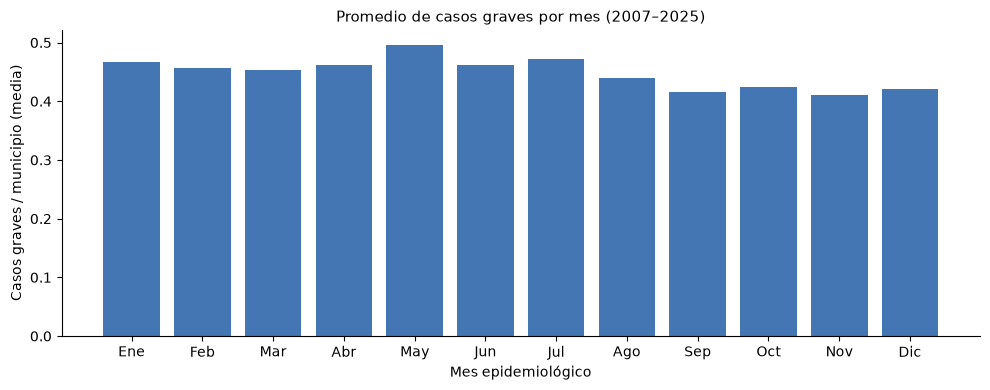


mes_sin  rango: -1.000 – 1.000
mes_cos  rango: -1.000 – 1.000
anio_epidemia: 0 – 18


In [5]:
# mes_sin/cos: codificación cíclica del mes (evita discontinuidad dic→ene)
# anio_epidemia: tendencia continua desde 2007 (= ANO - 2007)
# Ambas ya vienen pre-computadas en el dataset

season = df.groupby('MES')['grave'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(season.index, season.values, color='#1654A2', alpha=0.8, width=0.8)
ax.set_title('Promedio de casos graves por mes (2007–2025)', fontsize=11)
ax.set_xlabel('Mes epidemiológico')
ax.set_ylabel('Casos graves / municipio (media)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/figures/12_estacionalidad_grave.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\nmes_sin  rango: {df["mes_sin"].min():.3f} – {df["mes_sin"].max():.3f}')
print(f'mes_cos  rango: {df["mes_cos"].min():.3f} – {df["mes_cos"].max():.3f}')
print(f'anio_epidemia: {df["anio_epidemia"].min()} – {df["anio_epidemia"].max()}')

## 5. Features de canal endémico y endemicidad

El canal endémico (Bortman, 1999) clasifica el mes t-1 de cada municipio como:
- **0 – Normal**: `grave_lag_1` < P25 histórico
- **1 – Alerta**: P25 ≤ `grave_lag_1` < P75
- **2 – Exceso**: `grave_lag_1` ≥ P75

**Referencia: 2007–2021** (solo periodo de entrenamiento, para evitar fuga de datos).

**Corrección clave:** cuando P75 = 0 (97%+ de grupos municipio-mes sin casos históricos), cualquier caso > 0 se clasifica como zona 1 (alerta), no zona 2 (exceso).

In [6]:
print(f'Municipios endémicos (es_endemico=1): {df[df["es_endemico"]==1]["divipola"].nunique()} de {df["divipola"].nunique()}')

vc = df['zona_canal_lag1'].value_counts(dropna=False).sort_index()
vc.index = [str(i) for i in vc.index]
print('Zona canal lag1 (mensual):', dict(vc))
pct_exceso = (df['zona_canal_lag1'] == 2).mean() * 100
print(f'% en exceso (zona 2): {pct_exceso:.1f}%  (fix P75=0 aplicado)')

print(f'\np25  cobertura: {df["p25"].notna().mean()*100:.1f}%  |  rango: {df["p25"].min():.1f} – {df["p25"].max():.1f}')
print(f'p75  cobertura: {df["p75"].notna().mean()*100:.1f}%  |  rango: {df["p75"].min():.1f} – {df["p75"].max():.1f}')

Municipios endémicos (es_endemico=1): 139 de 1182
Zona canal lag1 (mensual): {'0': np.int64(74803), '1': np.int64(30159), '2': np.int64(6833)}
% en exceso (zona 2): 6.1%  (fix P75=0 aplicado)

p25  cobertura: 99.4%  |  rango: 0.0 – 4.5
p75  cobertura: 99.4%  |  rango: 0.0 – 31.5


In [7]:
# SIR mensual: grave_lag_1 / media_histórica(grave) por divipola+MES (ref 2007-2021)
print(f'SIR lag1 cobertura: {df["sir_lag1"].notna().mean()*100:.1f}%')
print(df['sir_lag1'].describe().round(3))

SIR lag1 cobertura: 63.6%
count    71071.000
mean         1.004
std          3.385
min          0.000
25%          0.000
50%          0.000
75%          0.000
max        322.000
Name: sir_lag1, dtype: float64


In [8]:
FEATURE_COLS = (
    [f'grave_lag_{l}'   for l in [1, 2, 3, 4, 6]] +
    [f'clasico_lag_{l}' for l in [1, 2, 3, 4, 6]] +
    ['grave_roll3', 'clasico_roll3'] +
    ['temp_mean_c', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3'] +
    ['rain_mm_day', 'rain_lag_1', 'rain_lag_2', 'rain_lag_3'] +
    ['mes_sin', 'mes_cos', 'anio_epidemia', 'ANO', 'MES'] +
    ['es_endemico', 'zona_canal_lag1', 'p25', 'p75', 'sir_lag1']
)
TARGET = 'grave'

GRUPOS = (
    ['rezago_grave']*5 + ['rezago_clasico']*5 + ['rolling']*2 +
    ['temperatura']*4  + ['lluvia']*4 + ['temporal']*5 + ['endemic_canal']*5
)

FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

rows = []
for c, g in zip(FEATURE_COLS, GRUPOS):
    sub = df[[c, TARGET]].dropna().reset_index(drop=True)
    corr_val = round(sub.corr().iloc[0, 1], 3) if len(sub) > 1 else float('nan')
    rows.append({'feature': c, 'grupo': g,
                 'cobertura_%': round(df[c].notna().mean()*100, 1),
                 'corr_grave': corr_val})

summary = pd.DataFrame(rows)
print(f'Total features: {len(FEATURE_COLS)}')
print(summary.to_string(index=False))

Total features: 30
        feature          grupo  cobertura_%  corr_grave
    grave_lag_1   rezago_grave         98.9       0.921
    grave_lag_2   rezago_grave         97.9       0.888
    grave_lag_3   rezago_grave         97.0       0.844
    grave_lag_4   rezago_grave         96.0       0.796
    grave_lag_6   rezago_grave         94.2       0.721
  clasico_lag_1 rezago_clasico         98.9       0.371
  clasico_lag_2 rezago_clasico         97.9       0.349
  clasico_lag_3 rezago_clasico         97.0       0.327
  clasico_lag_4 rezago_clasico         96.0       0.305
  clasico_lag_6 rezago_clasico         94.2       0.272
    grave_roll3        rolling        100.0       0.903
  clasico_roll3        rolling        100.0       0.352
    temp_mean_c    temperatura         96.4      -0.022
     temp_lag_1    temperatura         95.4      -0.022
     temp_lag_2    temperatura         94.5      -0.022
     temp_lag_3    temperatura         93.6      -0.021
    rain_mm_day         lluvi

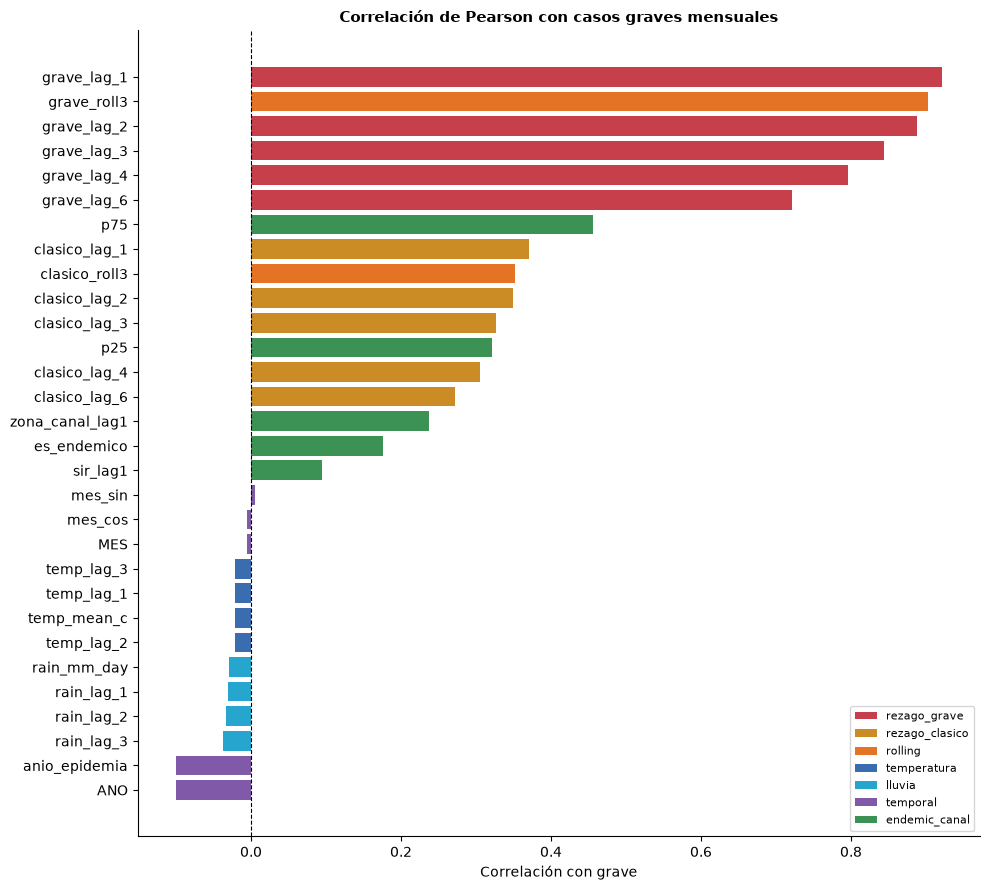

In [9]:
COLORS = {
    'rezago_grave':   '#BE1D2B',
    'rezago_clasico': '#C27800',
    'rolling':        '#E05A00',
    'temperatura':    '#1654A2',
    'lluvia':         '#0096C7',
    'temporal':       '#6A3D9A',
    'endemic_canal':  '#1A7F37',
}

ss = summary.dropna(subset=['corr_grave']).sort_values('corr_grave')
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(ss['feature'], ss['corr_grave'],
        color=[COLORS[g] for g in ss['grupo']], alpha=0.85)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Correlación de Pearson con casos graves mensuales',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Correlación con grave')
ax.spines[['top','right']].set_visible(False)
ax.legend(handles=[Patch(facecolor=v, label=k, alpha=0.85) for k, v in COLORS.items()],
          fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../data/figures/13_correlacion_features.png', dpi=130, bbox_inches='tight')
plt.show()

In [10]:
for name, split in [
    ('Train  2007–2021', df[df['ANO'] <= 2021]),
    ('Val    2022',      df[df['ANO'] == 2022]),
    ('Test   2023–2025', df[df['ANO'] >= 2023]),
]:
    n_pos = (split[TARGET] > 0).sum()
    print(f'{name}: {len(split):>7,} filas | {n_pos:,} positivos ({n_pos/len(split)*100:.1f}%)')

Train  2007–2021:  83,138 filas | 13,833 positivos (16.6%)
Val    2022:   5,308 filas | 717 positivos (13.5%)
Test   2023–2025:  23,349 filas | 3,164 positivos (13.6%)


## 10. Partición temporal (sin data leakage)

| Split | Años | Propósito |
|---|---|---|
| Entrenamiento | 2007–2021 | Ajuste de parámetros |
| Validación | 2022 | Selección de hiperparámetros |
| Prueba | 2023–2025 | Evaluación final (epidemia 2023 incluida) |

In [11]:
import os
path = DATA + 'dengue_features_modelado.csv'
size_mb = os.path.getsize(path) / 1e6
print(f'Archivo : {path}')
print(f'Tamaño  : {size_mb:.1f} MB')
print(f'Filas   : {len(df):,}  |  Columnas: {df.shape[1]}')
nulls = df[FEATURE_COLS].isnull().mean() * 100
print('\nNulos por feature:')
for col, pct in nulls[nulls > 0].sort_values(ascending=False).items():
    print(f'  {col}: {pct:.1f}%')
print('  (XGBoost maneja nulos nativamente)')

Archivo : ../data/processed/dengue_features_modelado.csv
Tamaño  : 30.3 MB
Filas   : 111,795  |  Columnas: 35

Nulos por feature:
  sir_lag1: 36.4%
  temp_lag_3: 6.4%
  rain_lag_3: 6.4%
  clasico_lag_6: 5.8%
  grave_lag_6: 5.8%
  temp_lag_2: 5.5%
  rain_lag_2: 5.5%
  temp_lag_1: 4.6%
  rain_lag_1: 4.6%
  clasico_lag_4: 4.0%
  grave_lag_4: 4.0%
  temp_mean_c: 3.6%
  rain_mm_day: 3.6%
  grave_lag_3: 3.0%
  clasico_lag_3: 3.0%
  grave_lag_2: 2.1%
  clasico_lag_2: 2.1%
  clasico_lag_1: 1.1%
  grave_lag_1: 1.1%
  p25: 0.6%
  p75: 0.6%
  clasico_roll3: 0.0%
  grave_roll3: 0.0%
  (XGBoost maneja nulos nativamente)


## 9. Variables descartadas (SIVIGILA individual)

| Grupo | Columnas | Razón |
|---|---|---|
| IDs administrativos | `CONSECUTIVE, COD_PRE, COD_SUB` | Sin valor predictivo |
| Variables de resultado | `PAC_HOS, CON_FIN, FEC_HOS, FEC_DEF` | Contemporáneas al caso, no leading |
| Tipo confirmación | `TIP_CAS, nom_est_f_caso` | Administrativo |
| Demografía | `SEXO, EDAD, AREA, TIP_SS` | Sin relación de adelanto temporal |
| >99% nulos | `FM_FUERZA, FM_UNIDAD, FM_GRADO` | Datos militares |
| >80% nulos | `estrato, fuente, nom_grupo, sem_ges` | - |
| Cobertura/grupo | `COD_ASE, GRU_POB, GP_* (12 cols)` | Sin relación epidemiológica directa |